In [13]:
from tensorflow.keras.datasets import fashion_mnist

# Fashion-MNISTデータの読み込み
(trainX, trainY), (testX, testY) = fashion_mnist.load_data()

print(trainX.shape, trainY.shape)   # 学習データのサイズ
print(testX.shape, testY.shape)     # 評価データのサイズ

(60000, 28, 28) (60000,)
(10000, 28, 28) (10000,)


9


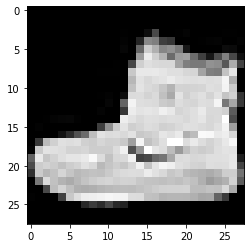

In [14]:
import matplotlib.pyplot as plt

# 1枚目のラベルを表示
print(trainY[0])

# 1枚目の画像を表示
plt.imshow(trainX[0], cmap='gray')
plt.show()

In [15]:
# AutoKerasのインストール
!pip install autokeras

In [16]:
import tensorflow as tf
import autokeras as ak

# 学習条件の設定
clf = ak.ImageClassifier(
    overwrite=True, # プロジェクト上書き
    max_trials=1)   # 試行回数
    
# モデルの学習
clf.fit(
    trainX/255,             # 説明変数（ピクセル値は255で割って正規化）
    trainY,                 # 目的変数
    validation_split=0.1,   # 全体の1割がテストデータ
    epochs=10)              # エポック数

Trial 1 Complete [00h 01m 32s]
val_loss: 0.22501465678215027

Best val_loss So Far: 0.22501465678215027
Total elapsed time: 00h 01m 32s
INFO:tensorflow:Oracle triggered exit
Epoch 1/10
1875/1875 [==============================] - 8s 4ms/step - loss: 0.4246 - accuracy: 0.8483
Epoch 2/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.3104 - accuracy: 0.8890
Epoch 3/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.2778 - accuracy: 0.9000
Epoch 4/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.2585 - accuracy: 0.9062
Epoch 5/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.2420 - accuracy: 0.9120
Epoch 6/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.2334 - accuracy: 0.9159
Epoch 7/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.2213 - accuracy: 0.9188
Epoch 8/10
1875/1875 [==============================] - 7s 4ms/step - loss: 0.2159 - accuracy: 0.9203
Epoch 9/10

In [17]:
from sklearn.metrics import classification_report

pred = clf.predict(testX).flatten().astype('int32')   # 評価データにモデルを適用
print(classification_report(testY, pred))             # モデル精度、再現率、適合率の計算

313/313 [==============================] - 0s 1ms/step
              precision    recall  f1-score   support

           0       0.86      0.76      0.81      1000
           1       0.99      0.93      0.96      1000
           2       0.89      0.50      0.64      1000
           3       0.93      0.81      0.86      1000
           4       0.61      0.91      0.73      1000
           5       0.96      0.90      0.93      1000
           6       0.58      0.66      0.62      1000
           7       0.96      0.92      0.94      1000
           8       0.84      0.99      0.91      1000
           9       0.92      0.96      0.94      1000

    accuracy                           0.83     10000
   macro avg       0.85      0.83      0.83     10000
weighted avg       0.85      0.83      0.83     10000



In [11]:
model = clf.export_model()    # 学習したモデルの出力
model.summary()               # 学習したモデルの概要

Model: "model"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 28, 28)]          0         
_________________________________________________________________
cast_to_float32 (CastToFloat (None, 28, 28)            0         
_________________________________________________________________
expand_last_dim (ExpandLastD (None, 28, 28, 1)         0         
_________________________________________________________________
normalization (Normalization (None, 28, 28, 1)         3         
_________________________________________________________________
conv2d (Conv2D)              (None, 26, 26, 32)        320       
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 24, 24, 64)        18496     
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 12, 12, 64)        0     